# Kunci Jawaban - Linear Regression

- **Dataset:** Medical Cost Personal Dataset / Insurance
- **Target:** `charges`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan boxplot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE, boxplot, dan regression plot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Siapkan file dataset Kaggle

Download dataset dari Kaggle, lalu letakkan file `insurance.csv` di folder kerja notebook.

In [5]:
DATA_PATH = "insurance.csv"

### Baca dataset CSV

Baca file `insurance.csv` menjadi DataFrame bernama `df`.

In [6]:
df = pd.read_csv(DATA_PATH)

### Tentukan kolom target

Simpan nama kolom target ke variabel `TARGET_COL`.

In [7]:
TARGET_COL = "charges"

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom dataset.

In [8]:
df.shape

(1338, 7)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki **1338 baris** dan **7 kolom**.

> Berapa jumlah fitur dan targetnya?

Jawaban: Dataset memiliki **6 fitur** dan **1 target**, yaitu `charges`.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat bentuk data.

In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Tidak, dataset memiliki kolom numerik dan kolom kategori seperti `sex`, `smoker`, dan `region`.

> Apakah dataset membutuhkan encoding kategori sebelum modeling?

Jawaban: Ya, kolom kategori perlu diubah menjadi numerik menggunakan one-hot encoding.

## 3 - Data Understanding

### Tampilkan informasi dataset

Gunakan `info()` untuk melihat tipe data dan jumlah data non-null.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


> Berdasarkan output `info()`, apa tipe data setiap kolom?

Jawaban: Dataset memiliki **3 kolom object**, **2 kolom int64**, dan **2 kolom float64**.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak, semua kolom memiliki jumlah non-null yang sama dengan jumlah baris dataset, yaitu **1338 non-null**.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [11]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value. Semua kolom memiliki missing value **0**.

> Apakah data perlu diisi menggunakan mean, median, atau metode imputasi lain?

Jawaban: Tidak perlu, karena dataset tidak memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris yang duplikat penuh.

In [12]:
df.duplicated().sum()

np.int64(1)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Terdapat **1 baris duplikat penuh**.

> Apa keputusan cleaning yang perlu dilakukan?

Jawaban: Baris duplikat perlu dihapus agar data tidak menghitung sampel yang sama lebih dari satu kali.

### Tampilkan statistik deskriptif

Gunakan `describe()` untuk melihat ringkasan nilai numerik pada dataset.

In [13]:
df.describe()

,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


> Berdasarkan statistik deskriptif, bagaimana perbedaan skala antar fitur?

Jawaban: Skala antar fitur berbeda. Contohnya, `charges` bernilai ribuan hingga puluhan ribu, sedangkan `age`, `bmi`, dan `children` jauh lebih kecil.

> Mengapa scaling diperlukan sebelum model dilatih?

Jawaban: Scaling diperlukan agar perbedaan satuan dan skala antar fitur tidak terlalu memengaruhi proses modeling.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh dari dataset.

In [14]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index agar nomor baris kembali rapi setelah duplikat dihapus.

In [15]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah duplikat dihapus.

In [16]:
df_clean.shape

(1337, 7)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Setelah duplikat dihapus, dataset memiliki **1337 baris** dan **7 kolom**.

> Berapa jumlah baris yang berkurang dari dataset awal?

Jawaban: Jumlah baris berkurang sebanyak **1 baris**, dari 1338 menjadi 1337 baris.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat yang tersisa.

In [17]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak, jumlah duplikat setelah cleaning adalah **0**.

> Jelaskan kondisi dataset setelah duplikat dihapus.

Jawaban: Dataset sudah bersih dari duplikat penuh dan siap digunakan untuk EDA serta modeling.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Lihat ringkasan statistik kolom target.

In [18]:
df_clean[TARGET_COL].describe()

count    1337.000
mean    13279.121
std     12110.360
min      1121.874
25%      4746.344
50%      9386.161
75%     16657.717
max     63770.428
Name: charges, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Target memiliki mean sekitar **13279.12**, nilai minimum sekitar **1121.87**, dan nilai maksimum sekitar **63770.43**.

> Apa yang bisa disimpulkan dari rentang nilai target tersebut?

Jawaban: Biaya asuransi memiliki rentang yang sangat lebar, sehingga nilai target cukup bervariasi.

### Buat histogram target

Gunakan histogram dengan garis KDE untuk melihat persebaran nilai target dan bentuk kurvanya.

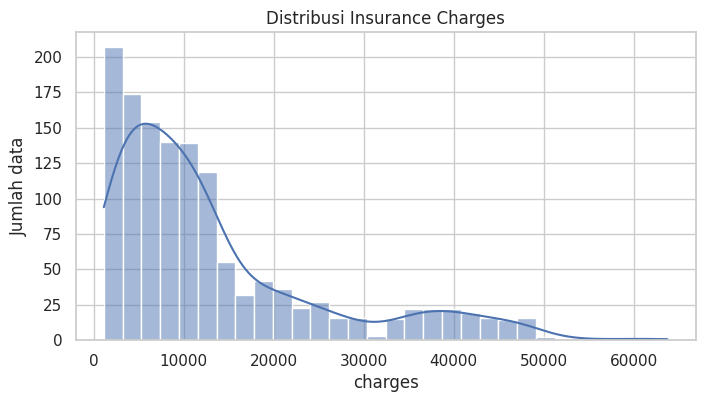

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi Insurance Charges")
plt.xlabel("charges")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Sebagian besar nilai `charges` muncul pada rentang biaya rendah sampai menengah.

> Apakah bentuk distribusinya mendekati lonceng sempurna atau condong ke salah satu sisi?

Jawaban: Distribusi condong ke kanan karena ada sebagian biaya asuransi yang sangat tinggi.

### Hitung korelasi fitur numerik dengan target

Hitung korelasi fitur numerik terhadap target.

In [20]:
numeric_corr = df_clean.select_dtypes(include="number").corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

age        0.298
bmi        0.198
children   0.067
Name: charges, dtype: float64

> Berdasarkan output korelasi, fitur numerik apa saja yang memiliki korelasi positif terhadap target?

Jawaban: `age`, `bmi`, dan `children` memiliki korelasi positif terhadap target.

> Fitur numerik mana yang paling kuat hubungannya dengan target?

Jawaban: `age` memiliki korelasi positif paling besar terhadap `charges` di antara fitur numerik awal.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat korelasi fitur numerik dengan target secara visual.

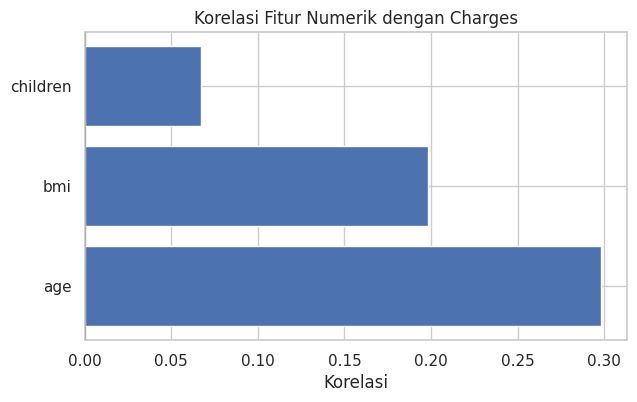

In [21]:
plt.figure(figsize=(7, 4))
plt.barh(numeric_corr.index, numeric_corr.values)
plt.axvline(0, color="black")
plt.title("Korelasi Fitur Numerik dengan Charges")
plt.xlabel("Korelasi")
plt.show()

> Berdasarkan bar plot, fitur numerik mana yang memiliki korelasi paling tinggi?

Jawaban: `age` memiliki korelasi paling tinggi terhadap `charges`.

> Apa arti korelasi positif pada fitur numerik tersebut?

Jawaban: Korelasi positif berarti nilai fitur cenderung naik bersama nilai `charges`.

### Buat boxplot Charges berdasarkan Smoker

Gunakan boxplot untuk membandingkan biaya asuransi pada kategori smoker.

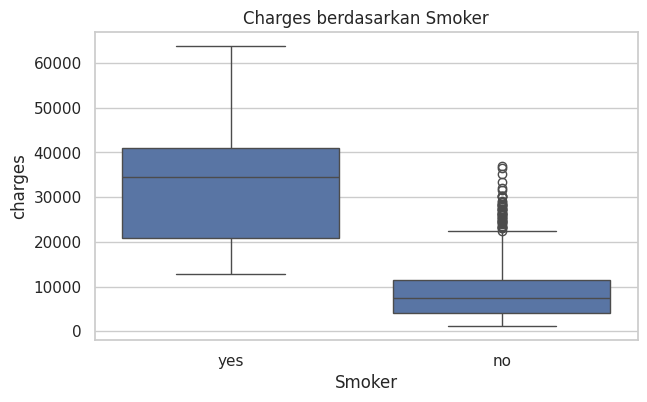

In [22]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="smoker", y=TARGET_COL)
plt.title("Charges berdasarkan Smoker")
plt.xlabel("Smoker")
plt.ylabel("charges")
plt.show()

> Berdasarkan boxplot, bagaimana perbedaan charges antara smoker dan non-smoker?

Jawaban: Kelompok smoker cenderung memiliki charges yang jauh lebih tinggi dibanding non-smoker.

> Mengapa boxplot tepat untuk fitur `smoker`?

Jawaban: Boxplot tepat karena `smoker` adalah fitur kategori dengan dua kelompok.

### Buat scatter plot Age dan target

Gunakan scatter plot dengan garis tren untuk melihat hubungan `age` dengan target.

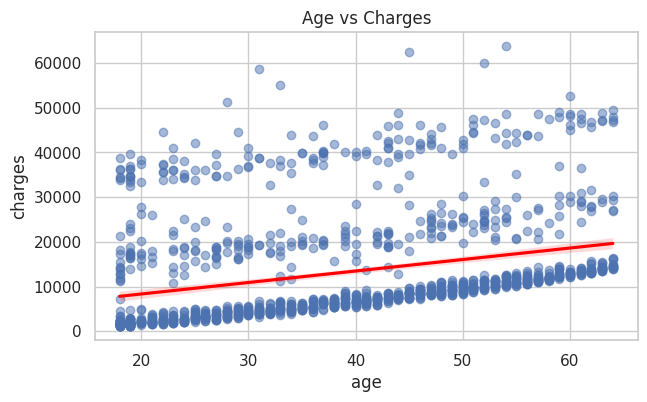

In [23]:
plt.figure(figsize=(7, 4))
sns.regplot(
    data=df_clean,
    x="age",
    y=TARGET_COL,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Age vs Charges")
plt.xlabel("age")
plt.ylabel("charges")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `age` dengan target?

Jawaban: Semakin tinggi usia, biaya asuransi cenderung meningkat.

> Apakah garis tren menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis tren menunjukkan arah hubungan **positif**.

## 6 - Feature dan Target

### Pisahkan fitur awal

Simpan semua kolom selain target ke variabel `X_raw_model`.

In [24]:
X_raw_model = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke variabel `y`.

In [25]:
y = df_clean[TARGET_COL]

### Encode fitur kategori

Ubah kolom kategori menjadi numerik menggunakan one-hot encoding.

In [26]:
X = pd.get_dummies(X_raw_model, drop_first=True)

### Tampilkan ukuran fitur setelah encoding

Cek ukuran `X` setelah fitur kategori di-encode.

In [27]:
X.shape

(1337, 8)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X` setelah encoding?

Jawaban: `X` memiliki **1337 baris** dan **8 fitur** setelah encoding.

### Tampilkan ukuran target

Cek ukuran `y` setelah target dipisahkan.

In [28]:
y.shape

(1337,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki **1337 nilai target**.

> Apakah jumlah baris `X` dan `y` sudah sama?

Jawaban: Ya, jumlah baris `X` dan `y` sudah sama, yaitu **1337**.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [29]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji yang digunakan adalah **20%**, sedangkan data latih adalah **80%** dari seluruh dataset.

### Bagi data train dan test

Bagi data menjadi data train dan test.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Cek jumlah data dan fitur pada `X_train`.

In [31]:
X_train.shape

(1069, 8)

### Tampilkan ukuran X_test

Cek jumlah data dan fitur pada `X_test`.

In [32]:
X_test.shape

(268, 8)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki **1069 baris**, sedangkan data test memiliki **268 baris**.

> Apakah jumlah fitur pada train dan test tetap sama?

Jawaban: Ya, jumlah fitur pada train dan test tetap sama, yaitu **8 fitur**.

## 8 - Feature Scaling

### Buat object scaler

Gunakan `StandardScaler` untuk menstandarkan fitur.

In [33]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler hanya pada data train, lalu transform data train.

In [34]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Transform data test menggunakan scaler yang sudah di-fit pada data train.

In [35]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [36]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [37]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan untuk prediksi?

Jawaban: Output `LinearRegression()` menunjukkan bahwa object model sudah berhasil dilatih dan siap digunakan untuk prediksi.

### Tampilkan intercept model

Tampilkan nilai intercept dari model.

In [38]:
model.intercept_

np.float64(13030.203369289053)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar **13030.20**.

> Apa makna intercept setelah seluruh fitur di-scale?

Jawaban: Intercept adalah nilai dasar prediksi ketika seluruh fitur berada pada titik nol setelah scaling.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel sederhana.

In [39]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_table.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
4,smoker_yes,9234.342
0,age,3472.976
1,bmi,1927.828
2,children,636.501
3,sex_male,-50.750
5,region_northwest,-168.944
7,region_southwest,-284.610
6,region_southeast,-371.781


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar dan koefisien negatif terbesar?

Jawaban: Koefisien positif terbesar adalah `smoker_yes` sekitar **9234.34**, sedangkan koefisien negatif terbesar adalah `region_southeast` sekitar **-371.78**.

> Apa arti tanda positif dan negatif pada koefisien?

Jawaban: Koefisien positif berarti fitur cenderung menaikkan prediksi, sedangkan koefisien negatif berarti fitur cenderung menurunkan prediksi.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk memprediksi data train.

In [40]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk memprediksi data test.

In [41]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama dari data test.

In [42]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": y_test_pred[:5]
})
prediction_preview

,Actual,Predicted
0,8688.859,8143.694
1,5708.867,5737.116
2,11436.738,14369.315
3,38746.355,31745.514
4,4463.205,8962.387


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dan paling jauh dari nilai aktual?

Jawaban: Prediksi paling dekat terlihat pada baris ke-2, dengan aktual sekitar **5708.87** dan prediksi sekitar **5737.12**. Prediksi paling jauh terlihat pada baris ke-5, dengan aktual sekitar **4463.21** dan prediksi sekitar **8962.39**.

> Apa yang bisa disimpulkan dari selisih aktual dan prediksi?

Jawaban: Beberapa prediksi cukup dekat, tetapi ada juga prediksi dengan selisih biaya yang besar.

### Hitung MAE train

Hitung rata-rata error absolut pada data train.

In [43]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

4181.9015377751475

### Hitung MAE test

Hitung rata-rata error absolut pada data test.

In [44]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

4177.045561036326

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar **4177.05**.

> Apa arti rata-rata error absolut tersebut?

Jawaban: Artinya, rata-rata prediksi model meleset sekitar **4177** dari biaya aktual.

### Hitung RMSE train

Hitung RMSE pada data train.

In [45]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(6081.106881541277)

### Hitung RMSE test

Hitung RMSE pada data test.

In [46]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(5956.342894363589)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar **5956.34**.

> Mengapa nilai RMSE dapat lebih besar daripada MAE?

Jawaban: RMSE dapat lebih besar daripada MAE karena RMSE memberi penalti lebih besar pada error yang besar.

### Hitung R2 train

Hitung R2 Score pada data train.

In [47]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.7299057809339075

### Hitung R2 test

Hitung R2 Score pada data test.

In [48]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.8069287081198011

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar **0.81**.

> Berapa persen variasi target pada data test yang dapat dijelaskan oleh model?

Jawaban: Model dapat menjelaskan sekitar **81%** variasi charges pada data test.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 ke dalam satu tabel ringkas.

In [49]:
evaluation_table = pd.DataFrame({
    "Subset": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
})
evaluation_table

,Subset,MAE,RMSE,R2
0,Train,4181.902,6081.107,0.730
1,Test,4177.046,5956.343,0.807


> Berdasarkan tabel evaluasi, bandingkan MAE, RMSE, dan R2 pada data train dan data test.

Jawaban: MAE test sedikit lebih kecil daripada MAE train, RMSE test lebih kecil daripada RMSE train, dan R2 test lebih besar daripada R2 train.

> Berapa persen perbedaannya, dan apa makna perbandingan tersebut?

Jawaban: MAE test sekitar **0.12%** lebih kecil, RMSE test sekitar **2.05%** lebih kecil, dan R2 test sekitar **10.55%** lebih besar dibanding train. Performa test terlihat baik pada split ini.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk melihat kedekatan nilai aktual dan prediksi pada data test.

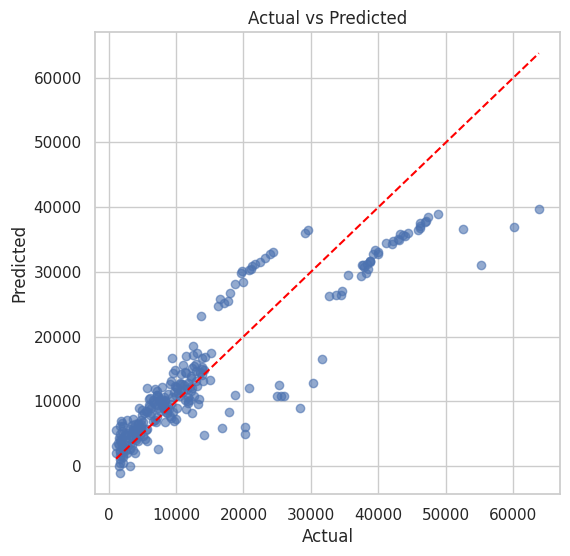

In [50]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 11 - Kesimpulan

Dataset Medical Cost Personal Dataset / Insurance digunakan untuk memprediksi `charges` atau biaya asuransi kesehatan berdasarkan data demografi dan kebiasaan. Data tidak memiliki missing value dan memiliki **1** baris duplikat penuh. Setelah cleaning, dataset memiliki **1337** baris dan **7** kolom.

Hasil EDA menunjukkan bahwa `age`, `bmi`, dan `children` memiliki hubungan positif dengan target secara numerik, dan fitur kategori `smoker` terlihat sangat membedakan nilai charges. Kolom kategori diubah menjadi numerik menggunakan `pd.get_dummies()`. Data dibagi menjadi **80%** data train dan **20%** data test, lalu fitur di-scale menggunakan `StandardScaler`.

Model Linear Regression menghasilkan MAE test sekitar **4177.05**, RMSE test sekitar **5956.34**, dan R2 test sekitar **0.81**. Berdasarkan metrik tersebut, model mampu menjelaskan sekitar **81%** variasi target pada data test dengan rata-rata error absolut sekitar **4177**.